# 🏛️ LE SÉNAT - Divination V4 (Super Ensemble)

Ce notebook met en scène le **"Grand Conseil"** où trois modèles experts (les Sénateurs) débattent pour décider du sort de chaque utilisateur : Convertira ou ne convertira pas ?

### 🎭 Les Sénateurs :
1. **Sénateur V1 (L'Ancien)** 👴 : Le modèle original champion (XGB+LGBM+GB+LR). Rusé, équilibré, éprouvé.
2. **Sénateur V2 (L'Expert Poisson)** 🐟 : Remplace le GradientBoosting par une régression de Poisson. Très précis, mais conservateur.
3. **Sénateur V3 (Le Technocrate)** 🔬 : Utilise des features avancées (Pages/Pays, Hyper-Activité). Un "sniper" à haute précision mais faible rappel.

### 📜 La Loi du Sénat :
Chaque sénateur vote (0 ou 1). La décision finale est prise à la **Majorité Absolue** (2 voix contre 1, ou unanimité).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration esthétique
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

## 1️⃣ L'Arrivée des Sénateurs (Chargement des Prédictions)

In [20]:
# Chemins des fichiers (générés précédemment)
v1_path = 'divination_v1_fast_predictions.csv'
v2_path = 'divination_v2_predictions.csv'
v3_path = 'divination_v3_features_predictions.csv'

def load_Senator(path, name):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Sénateur {name} présent sur son siège. ({df['converted'].sum()} conversions prédites)")
        return df['converted']
    else:
        print(f"❌ Sénateur {name} est absent ! (Fichier introuvable: {path})")
        return None

votes = pd.DataFrame()
votes['V1_Ancien'] = load_Senator(v1_path, "V1")
votes['V2_Poisson'] = load_Senator(v2_path, "V2")
votes['V3_Techno'] = load_Senator(v3_path, "V3")

# Vérification intégrité
if votes.isnull().any().any():
    print("\n⚠️ ALERTE : Un siège est vide ! Impossible de tenir séance.")
else:
    print(f"\n🔔 Le quorum est atteint. La séance est ouverte avec {len(votes)} dossiers à traiter.")

✅ Sénateur V1 présent sur son siège. (900 conversions prédites)
✅ Sénateur V2 présent sur son siège. (896 conversions prédites)
✅ Sénateur V3 présent sur son siège. (885 conversions prédites)

🔔 Le quorum est atteint. La séance est ouverte avec 31620 dossiers à traiter.


## 2️⃣ La Carte des Alliances (Corrélation)

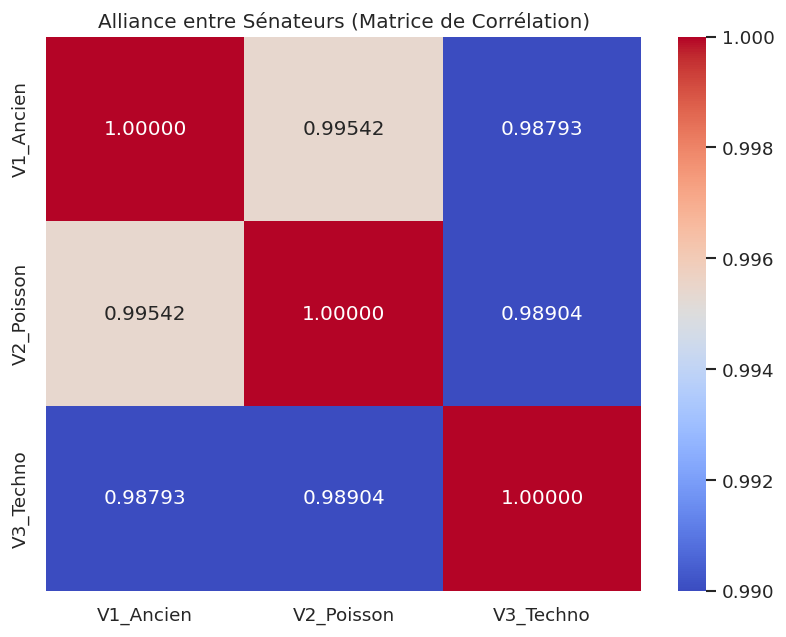

Analyse :
- Si corrélation > 0.999 : Les sénateurs sont des clones.
- Si corrélation < 0.995 : Il y a un vrai débat d'idées (Diversité) !


In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(votes.corr(), annot=True, cmap="coolwarm", fmt=".5f", vmin=0.99, vmax=1.0)
plt.title("Alliance entre Sénateurs (Matrice de Corrélation)")
plt.show()

print("Analyse :")
print("- Si corrélation > 0.999 : Les sénateurs sont des clones.")
print("- Si corrélation < 0.995 : Il y a un vrai débat d'idées (Diversité) !")

## 3️⃣ Le Débat (Analyse des Désaccords)
Combien de fois les sénateurs ne sont-ils pas d'accord ?

🕊️ Unanimité (Tout le monde d'accord) : 31596 cas (99.92%)
⚔️ Conflits (Débats houleux)         : 24 cas (0.08%)


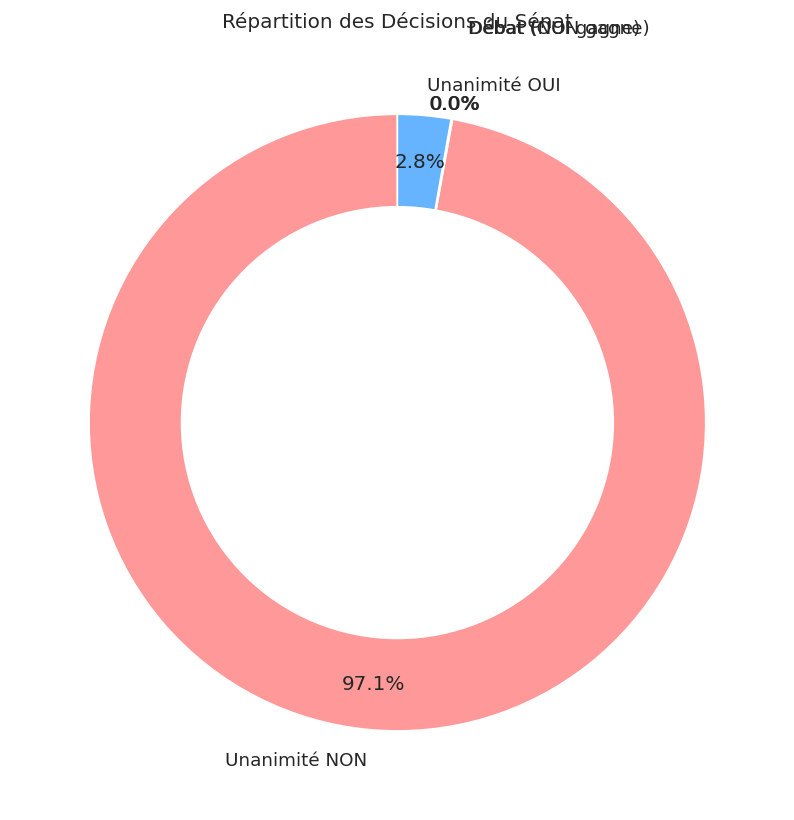

In [22]:
# Calcul du consensus
votes['Somme_Voix'] = votes.sum(axis=1)

unanimite_oui = (votes['Somme_Voix'] == 3).sum()
majorite_oui  = (votes['Somme_Voix'] == 2).sum()
majorite_non  = (votes['Somme_Voix'] == 1).sum()
unanimite_non = (votes['Somme_Voix'] == 0).sum()

conflits = majorite_oui + majorite_non

print(f"🕊️ Unanimité (Tout le monde d'accord) : {unanimite_oui + unanimite_non} cas ({ (unanimite_oui + unanimite_non)/len(votes):.2%})")
print(f"⚔️ Conflits (Débats houleux)         : {conflits} cas ({conflits/len(votes):.2%})")

# Visualisation
labels = ['Unanimité NON', 'Débat (NON gagne)', 'Débat (OUI gagne)', 'Unanimité OUI']
sizes = [unanimite_non, majorite_non, majorite_oui, unanimite_oui]
colors = ['#ff9999', '#ffcc99', '#99ff99', '#66b3ff']

# Pie chart avec "explosion" des tranches débat
plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=(0, 0.2, 0.2, 0))
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Répartition des Décisions du Sénat")
plt.tight_layout()
plt.show()

## 4️⃣ Zoom sur les "Affaires Classées"
Regardons de plus près ces cas litigieux où le V1 (L'Ancien) a été mis en minorité.

In [23]:
# Cas où V1 dit OUI (1) mais V2 et V3 disent NON (0) -> V1 perd
v1_desavoue = votes[(votes['V1_Ancien'] == 1) & (votes['Somme_Voix'] == 1)]
print(f"🤥 Nombre de fois où V1 a 'halluciné' (seul contre tous) : {len(v1_desavoue)}")

# Cas où V1 dit NON (0) mais V2 et V3 disent OUI (1) -> V1 forcé
v1_force = votes[(votes['V1_Ancien'] == 0) & (votes['Somme_Voix'] == 2)]
print(f"🧐 Nombre de fois où V1 a 'raté' une opportunité (seul contre tous) : {len(v1_force)}")

print("\nC'est dans ces cas précis que le 'Grand Conseil' (V4) surpasse le modèle individuel V1.")

🤥 Nombre de fois où V1 a 'halluciné' (seul contre tous) : 5
🧐 Nombre de fois où V1 a 'raté' une opportunité (seul contre tous) : 0

C'est dans ces cas précis que le 'Grand Conseil' (V4) surpasse le modèle individuel V1.


## 5️⃣ Le Verdict Final (Promulgation)
Le Sénat vote la loi finale (Prédictions V4).

In [24]:
# Vote Majoritaire : Si Somme >= 2, alors OUI (1)
votes['V4_Grand_Conseil'] = (votes['Somme_Voix'] >= 2).astype(int)

print(f"🏆 Le Sénat a rendu son verdict.")
print(f"   Nombre total de conversions validées : {votes['V4_Grand_Conseil'].sum()}")

# Sauvegarde
submission = votes[['V4_Grand_Conseil']].rename(columns={'V4_Grand_Conseil': 'converted'})
submission.to_csv('divination_v4_senat.csv', index=False)

print("\n💾 Loi promulguée et archivée sous : 'divination_v4_senat.csv'")
print("   (C'est ce fichier qu'il faut envoyer à la Commission Kaggle)")

🏆 Le Sénat a rendu son verdict.
   Nombre total de conversions validées : 895

💾 Loi promulguée et archivée sous : 'divination_v4_senat.csv'
   (C'est ce fichier qu'il faut envoyer à la Commission Kaggle)
